## Homography Matrix

### Calibration

In [2]:
import numpy as np
import cv2
# Clicked at: (254, 66)
# Clicked at: (363, 82)
# Clicked at: (302, 112)
# Clicked at: (423, 113)
# Clicked at: (278, 156)
# Clicked at: (362, 173)
# Clicked at: (348, 183)
# Clicked at: (300, 229)
# Clicked at: (422, 232)
# Clicked at: (284, 262)
# Clicked at: (360, 262)
pixel_coordinates = np.array([
    [254, 66],
    [363, 82],
    [302, 112],
    [423, 113],
    [278, 156],
    [362, 173],
    [348, 183],
    [300, 229],
    [422, 232],
    [284, 262],
    [360, 262]
], dtype=np.float32)
robot_coordinates = [[393.6,-47.6], [245.8,-29.9], [325.3,11.4], [164.9,7.9], [356.9,73.4], [244.5,92.9], [262.6,107.8], [323.9,170.4], [164.6,168.5], [343.1,215.1], [243.9,212.2]]
pixel_points = np.array(pixel_coordinates, dtype=np.float32)
robot_points = np.array(robot_coordinates, dtype=np.float32)

homography_matrix, _ = cv2.findHomography(pixel_points, robot_points)
print("Homography Matrix:", homography_matrix)

Homography Matrix: [[-1.35714105e+00 -2.38796767e-03  7.44071239e+02]
 [-4.60044555e-02  1.40186327e+00 -1.29945190e+02]
 [ 2.97835843e-05  1.28155828e-04  1.00000000e+00]]


In [ ]:
predicted_robot_coords = []
for point in pixel_coordinates:
    x, y = point
    robot_x, robot_y = pixel_to_robot(x, y, homography_matrix)
    predicted_robot_coords.append([robot_x, robot_y])
predicted_robot_coords = np.array(predicted_robot_coords, dtype=np.float32)
print("Predicted Robot Coordinates:", predicted_robot_coords)

mse = np.mean((predicted_robot_coords - robot_points) ** 2)
print("Mean Square Error:", mse)

Predicted Robot Coordinates: [[392.90417  -48.332893]
 [245.9887   -31.030443]
 [326.32806   12.869668]
 [165.2556     8.768036]
 [356.33905   73.867836]
 [244.322     92.86345 ]
 [262.47305  106.96885 ]
 [323.97925  170.74362 ]
 [163.8718   168.73555 ]
 [343.57523  215.23044 ]
 [244.06308  211.4159  ]]
Mean Square Error: 0.42270482


## Move to home position

In [15]:
import cv2
import numpy as np
from xarm.wrapper import XArmAPI


arm = XArmAPI('192.168.1.155')
arm.motion_enable(enable=True)
arm.set_mode(0)
arm.set_state(0)
arm.connect()
arm.move_gohome()

ROBOT_IP: 192.168.1.155, VERSION: v2.2.0, PROTOCOL: V1, DETAIL: 6,9,LI1006,DL1000,v2.2.0, TYPE1300: [0, 0]
change protocol identifier to 3


0

ControllerWarning, code: 14


## Pixel to robot conversion

In [7]:
def pixel_to_robot(x, y, matrix):
    pixel = np.array([x, y, 1]).reshape(3, 1)
    robot_coords = np.dot(matrix, pixel)
    robot_coords /= robot_coords[2]  
    return robot_coords[0][0], robot_coords[1][0]

In [17]:
# Clicked at: (250, 349)
# box = pixel_to_robot(251,  54, homography_matrix)
# box_x, box_y = box

## Pick up and drop sub routine

In [18]:
import time
def pick_up_and_drop(x_robot, y_robot, z, box_x, box_y):
    code, _ = arm.get_inverse_kinematics([x_robot, y_robot, z, 180, 0, 0])
    if code != 0:
        print("Unreachable!")
        return
    arm.set_position(x_robot, y_robot, 70, speed=100)  
    arm.set_position(x_robot, y_robot, z, speed=100, wait=True)  
    arm.set_suction_cup(False)
    time.sleep(1)
    # arm.set_position(x_robot, y_robot, 16.5, wait=True)  
    arm.set_position(x_robot, y_robot, 70, speed=100, wait=True)  
    arm.set_position(box_x, box_y, 200, speed=100)
    arm.set_position(box_x, box_y, 100, speed=100)
    arm.set_suction_cup(True)
    arm.set_position(box_x, box_y, 200, speed=100)

In [19]:
import cv2

cap = cv2.VideoCapture(1)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame. Exiting...")
        break

    cv2.imshow('Webcam Preview - Press Q to capture', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        cv2.imwrite('captured_image.jpg', frame)
        print("Image saved as captured_image.jpg")
        break

cap.release()
cv2.destroyAllWindows()

Image saved as captured_image.jpg


In [20]:
import dotenv
import os
from google import genai
from google.genai import types
from PIL import Image
import io
import os
import requests
from io import BytesIO

dotenv.load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

model_name = "gemini-2.0-flash" 

bounding_box_system_instructions = """
    Return bounding boxes as a JSON array with labels. Never return masks or code fencing. Limit to 25 objects.
    If an object is present multiple times, name them according to their unique characteristic (colors, size, position, unique characteristics, etc..).
    """

client = genai.Client(api_key=GEMINI_API_KEY)

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

In [21]:
import json
import random
import io
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    font = ImageFont.load_default()

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font)

    # Display the image
    img.save("output_image.jpg")  # or "output_image.png"
    print("Image saved as output_image.jpg")

    img.show()

In [ ]:
def parse_json(json_output):
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  
            json_output = json_output.split("```")[0]  
            break  
    return json_output

In [ ]:
prompt = "Detect the 2d bounding boxes of the cube (labeled as color of the cube)" 
# \"bottle, crushed paper, cap, metal outside the brown box"  # @param {type:"string"}

image = "captured_image.jpg"

im = Image.open(io.BytesIO(open(image, "rb").read()))
im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
    )
)

print(response.text)

```json
[
  {"box_2d": [243, 510, 297, 546], "label": "yellow cube"},
  {"box_2d": [320, 242, 372, 282], "label": "blue cube"},
  {"box_2d": [354, 459, 404, 494], "label": "blue cube"},
  {"box_2d": [360, 567, 410, 602], "label": "yellow cube"},
  {"box_2d": [197, 243, 250, 284], "label": "yellow cube"}
]
```


In [24]:
plot_bounding_boxes(im, response.text)

(640, 480)
Image saved as output_image.jpg


## Pick up routine

bottle = 157.5
metal = 16.8
cap = 16
paper = 25.8

In [ ]:
import torch
bounding_boxes = parse_json(response.text)
# save bounding boxes to a file
with open("bounding_box.json", "w") as f:
    f.write(bounding_boxes)
    
for i, bounding_box in enumerate(json.loads(bounding_boxes)):

    width, height = im.size
    
    abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
    abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
    abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
    abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

    if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

    if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y
    
    centroid1 = (abs_x1 + abs_x2) / 2
    centroid2 = (abs_y1 + abs_y2) / 2
    box_x = 0
    box_y = 0
    z = 0
   
    if "green" in bounding_box['label']:
        z = 31.3
        box_x = 132.4
        box_y = -183.8
    elif "blue" in bounding_box['label']:
        z = 31.3
        box_x = 314.7
        box_y = -173
    elif "yellow" in bounding_box['label']:
        z = 31.3
        box_x = 243.3
        box_y = -170.4
        
    c1_robot, c2_robot = pixel_to_robot(centroid1, centroid2, homography_matrix)
    pick_up_and_drop(c1_robot, c2_robot, z, box_x, box_y)
arm.move_gohome()

[SDK][ERROR][2025-04-09 11:56:57][base.py:380] - - API -> set_tgpio_digital(ionum=0, value=0) -> code=2
[SDK][ERROR][2025-04-09 11:56:57][base.py:380] - - API -> set_tgpio_digital(ionum=1, value=1) -> code=2
[SDK][ERROR][2025-04-09 11:56:57][base.py:380] - - API -> set_suction_cup(on=False, wait=False, delay_sec=None) -> code=2
[SDK][ERROR][2025-04-09 11:56:59][base.py:380] - - API -> set_tgpio_digital(ionum=0, value=1) -> code=2
[SDK][ERROR][2025-04-09 11:56:59][base.py:380] - - API -> set_tgpio_digital(ionum=1, value=0) -> code=2
[SDK][ERROR][2025-04-09 11:56:59][base.py:380] - - API -> set_suction_cup(on=True, wait=False, delay_sec=None) -> code=2
Unreachable!
[SDK][ERROR][2025-04-09 11:57:08][base.py:380] - - API -> set_tgpio_digital(ionum=0, value=0) -> code=2
[SDK][ERROR][2025-04-09 11:57:08][base.py:380] - - API -> set_tgpio_digital(ionum=1, value=1) -> code=2
[SDK][ERROR][2025-04-09 11:57:08][base.py:380] - - API -> set_suction_cup(on=False, wait=False, delay_sec=None) -> code=

0

## Plot pixel_to_robot coordinates and the actual coordinates

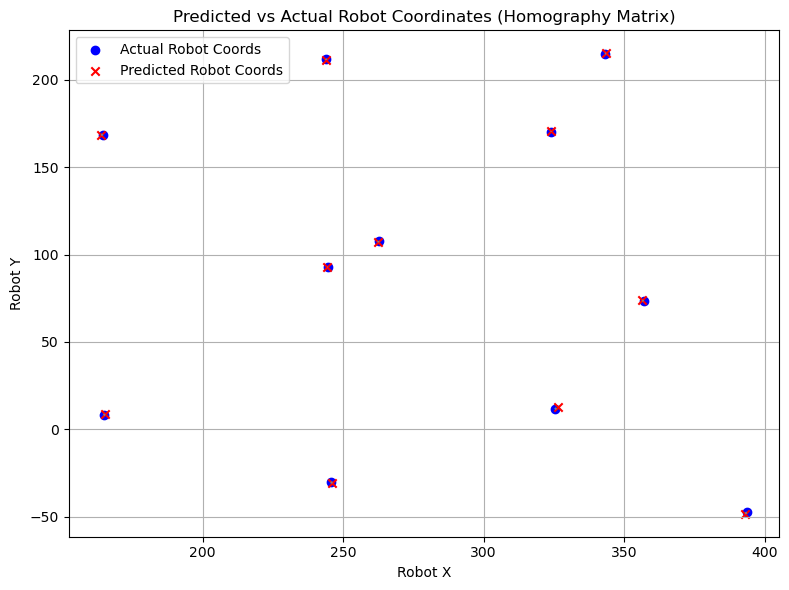

In [26]:
import matplotlib.pyplot as plt
import numpy as np

predicted_robot_coordinates = []
for pixel in pixel_coordinates:
    x, y = pixel
    predicted_x, predicted_y = pixel_to_robot(x, y, homography_matrix)
    predicted_robot_coordinates.append([predicted_x, predicted_y])

predicted_robot_coordinates = np.array(predicted_robot_coordinates)

robot_coordinates = np.array(robot_coordinates)

predicted_robot_coordinates = np.array(predicted_robot_coordinates)

plt.figure(figsize=(8, 6))
plt.scatter(robot_coordinates[:, 0], robot_coordinates[:, 1], label='Actual Robot Coords', color='blue')
plt.scatter(predicted_robot_coordinates[:, 0], predicted_robot_coordinates[:, 1], label='Predicted Robot Coords', color='red', marker='x')

for i in range(len(robot_coordinates)):
    plt.plot([robot_coordinates[i, 0], predicted_robot_coordinates[i, 0]],
             [robot_coordinates[i, 1], predicted_robot_coordinates[i, 1]], 'gray', linestyle='dotted')

plt.title("Predicted vs Actual Robot Coordinates (Homography Matrix)")
plt.xlabel("Robot X")
plt.ylabel("Robot Y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()